In [3]:
import pandas as pd
df =pd.read_csv("tips.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   gender      244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [4]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


In [5]:
df['day'].value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

In [6]:
df['day'].value_counts(normalize=True)

day
Sat     0.356557
Sun     0.311475
Thur    0.254098
Fri     0.077869
Name: proportion, dtype: float64

<BarContainer object of 4 artists>

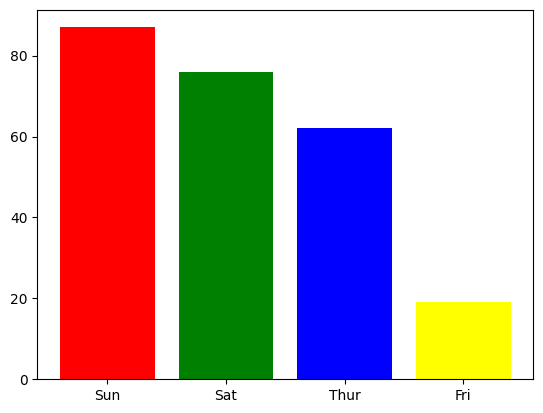

In [7]:
import matplotlib.pyplot as plt

plt.bar(
    x=df['day'].unique(), 
    height=df['day'].value_counts(), 
    color=["red", "green", "blue", "yellow"] )


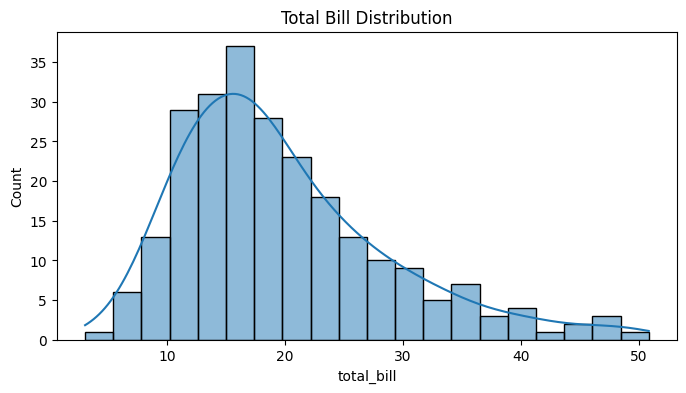

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))
sns.histplot(df['total_bill'], kde=True, bins=20)
plt.title('Total Bill Distribution')
plt.show()


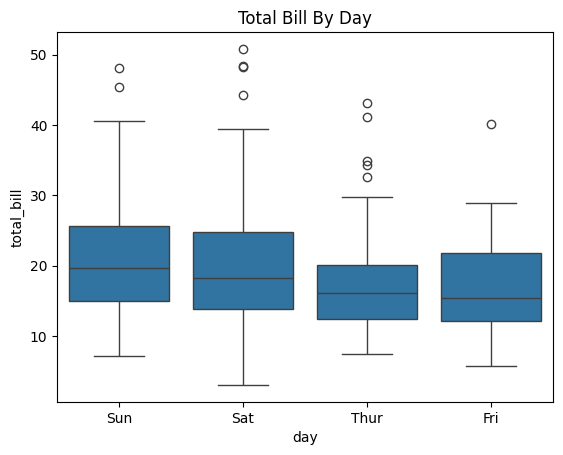

In [9]:
sns.boxplot(x='day', y='total_bill', data=df)
plt.title('Total Bill By Day')
plt.show()

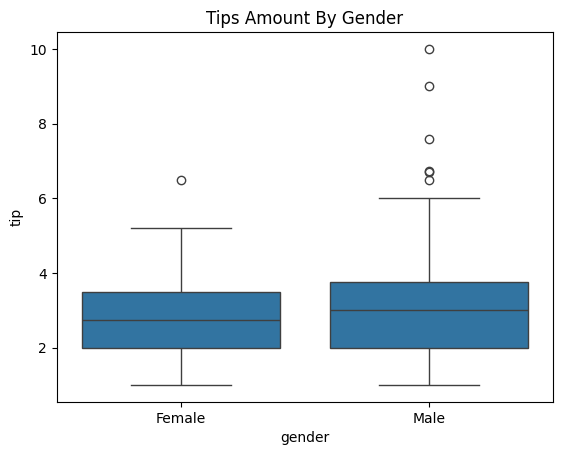

In [10]:
sns.boxplot(x='gender', y='tip', data=df)
plt.title('Tips Amount By Gender')
plt.show()

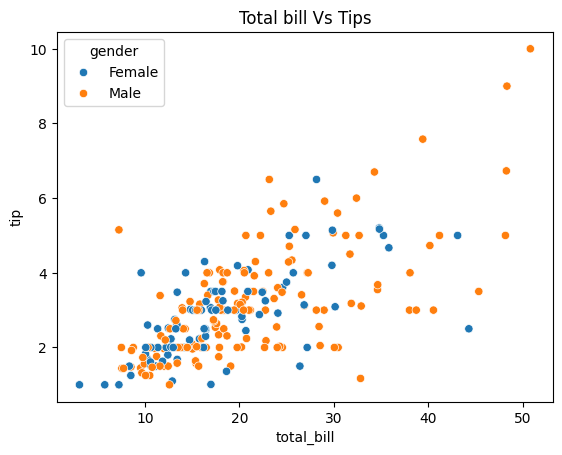

In [11]:
sns.scatterplot(x='total_bill', y='tip', hue='gender', data=df)
plt.title('Total bill Vs Tips')
plt.show()

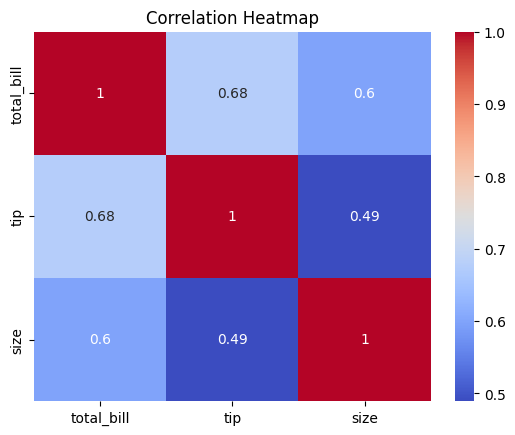

In [12]:
corr_mat = df.select_dtypes(include="number").corr()
sns.heatmap(corr_mat, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [16]:
from scipy import stats

contigency_table = pd.crosstab(df['gender'], df['smoker'])

chi2, p, dof, expected = stats.chi2_contingency(contigency_table, correction=False)

print(f"Chi2: {chi2}, P-value: {p}")


Chi2: 0.001934818536627623, P-value: 0.964915107315732


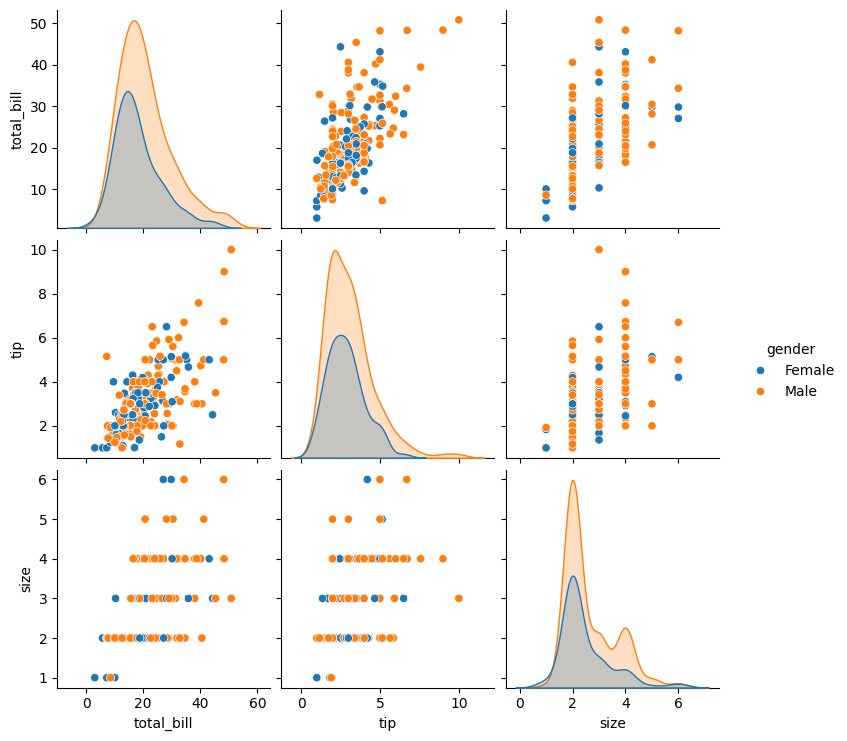

In [17]:
sns.pairplot(df, hue='gender')
plt.show()

In [ ]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="EDA Report")
profile.to_file("eda_report.html")


In [ ]:
df.memory_usage(deep=True).sum()  / 1024**2

In [ ]:
df.select_dtypes(include='number').columns.to_list()